# Phase 1 — 1D Fundamentals: Advection, Diffusion, and Burgers

The geophysical models later in this book are built from three elementary processes: **transport** (advection), **smoothing** (diffusion), and their **nonlinear coupling**. Each one already contains a numerical lesson that survives all the way up to the shallow-water and quasi-geostrophic models — the CFL limit of explicit advection, the much tighter stability limit of explicit diffusion, and the steepening-versus-smoothing balance that sets the grid Péclet number. This chapter develops the three in one dimension, where the physics is transparent and the somax models run in milliseconds {cite}`leveque2002finite,durran2010numerical`.

**What you will learn**

- Why linear advection on a periodic ring is a pure phase shift, and what the CFL number controls
- Why explicit diffusion is limited by $\Delta t \lesssim \Delta x^2 / (2\nu)$, not $\Delta x$
- How the nonlinear Burgers flux steepens a smooth wave into a shock, and how viscosity arrests it

## 1. Linear advection — transport without distortion

The 1-D linear advection equation moves a field $u(x,t)$ at constant speed $c$ without changing its shape,

```{math}
:label: p1-advection
\partial_t u + c\,\partial_x u = 0,
```

with exact solution $u(x,t) = u_0(x - ct)$ — the initial profile translated rigidly. On a periodic domain the solution returns to its start after one transit time $L/c$. The numerical challenge is that an explicit scheme can only see information within a few cells per step, so the time step is bounded by the **Courant–Friedrichs–Lewy (CFL)** condition

```{math}
:label: p1-cfl
\mathrm{CFL} \;=\; \frac{c\,\Delta t}{\Delta x} \;\le\; \mathrm{CFL}_{\max},
```

where $\mathrm{CFL}_{\max}$ is an $O(1)$ constant set by the time integrator. Above it the scheme is unstable; well below it, numerical diffusion smears the profile. Equation {eq}`p1-cfl` is the one-dimensional ancestor of the gravity-wave CFL that governs every shallow-water run.

In [1]:
import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import importlib.util
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import (
    Burgers1D,
    Burgers1DState,
    Diffusion1D,
    Diffusion1DState,
    LinearConvection1D,
    LinearConvection1DState,
)

In [2]:
try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p numpy,jax,matplotlib,somax")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

watermark extension not installed; skipping reproducibility readout.


In [3]:
IMG_DIR = Path.cwd().parent / "images" / "phase1_fundamentals"
IMG_DIR.mkdir(parents=True, exist_ok=True)

We advect a smooth Gaussian pulse one full transit around a periodic ring. The exact solution returns it to the start; the discrete solution shows the small numerical dispersion/diffusion an explicit upwind scheme introduces over one revolution.

In [4]:
conv = LinearConvection1D.create(nx=200, Lx=1.0, c=1.0)
xc = jnp.linspace(0.0, 1.0, conv.grid.Nx)
pulse0 = jnp.exp(-0.5 * ((xc - 0.3) / 0.05) ** 2)
conv_state0 = conv.apply_boundary_conditions(LinearConvection1DState(u=pulse0))

# One full transit of the periodic domain: t = L / c.
conv_sol = conv.integrate(conv_state0, t0=0.0, t1=1.0, dt=2.0e-3)
pulse_final = conv_sol.ys.u[-1]

cfl = conv.params.c * 2.0e-3 / conv.grid.dx
print(f"advection CFL = {cfl:.3f}")

advection CFL = 0.400


{numref}`p1-advection-fig` overlays the initial pulse and the field after one full revolution. With the CFL number printed above (well inside the stable range) the pulse returns close to where it started; the slight amplitude loss and broadening is the scheme's numerical diffusion.

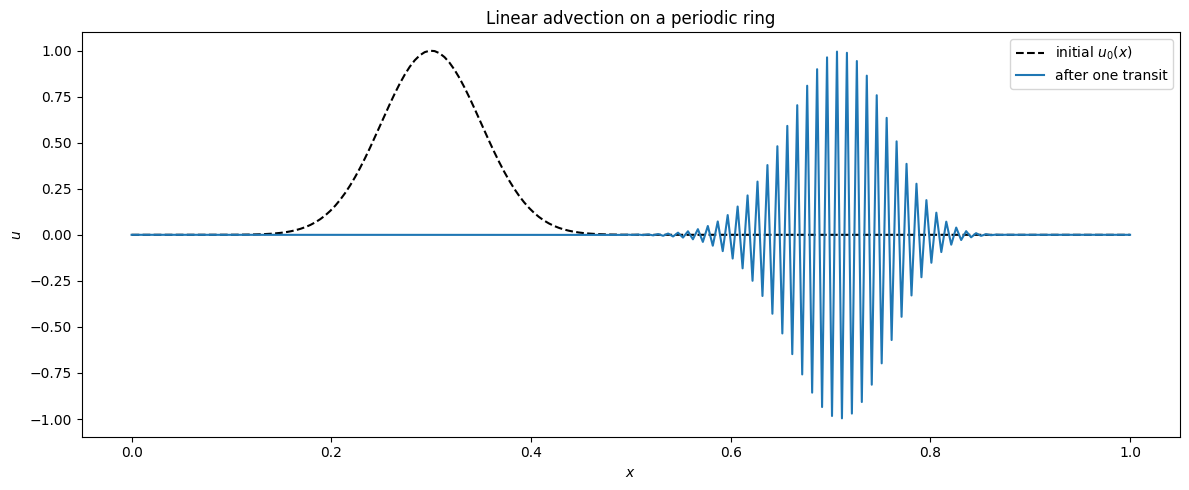

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(xc, pulse0, "k--", label="initial $u_0(x)$")
ax.plot(xc, pulse_final, "C0", label="after one transit")
ax.set(xlabel="$x$", ylabel="$u$", title="Linear advection on a periodic ring")
ax.legend()
fig.tight_layout()
fig.savefig(IMG_DIR / "advection_transit.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/phase1_fundamentals/advection_transit.png
:label: p1-advection-fig
:width: 90%

A Gaussian pulse advected one full transit of a periodic domain at unit speed. The dashed curve is the initial condition; the solid curve is the numerical solution after returning to its start. The small broadening is implicit numerical diffusion from the upwind reconstruction.
```

## 2. Diffusion — smoothing and the parabolic time-step limit

The 1-D diffusion (heat) equation spreads a field at rate set by the diffusivity $\nu$,

```{math}
:label: p1-diffusion
\partial_t u = \nu\,\partial_{xx} u .
```

A Gaussian stays Gaussian, with its variance growing linearly in time, so a blob of initial width $\sigma_0$ has width $\sqrt{\sigma_0^2 + 2\nu t}$. The crucial numerical fact is that an *explicit* discretisation of {eq}`p1-diffusion` is stable only for

```{math}
:label: p1-diffusion-cfl
\frac{\nu\,\Delta t}{\Delta x^2} \;\le\; \frac{1}{2},
```

a limit that scales with $\Delta x^2$, not $\Delta x$. Refining the grid by two therefore demands a *four-fold* smaller step — the reason stiff diffusion is the term somax tags `implicit` for IMEX integration (see the [composable-models tutorial](composable_models_terms_operators_cycles.ipynb)).

In [6]:
diff_model = Diffusion1D.create(nx=200, Lx=1.0, nu=2.0e-3)
xd = jnp.linspace(0.0, 1.0, diff_model.grid.Nx)
blob0 = jnp.exp(-0.5 * ((xd - 0.5) / 0.04) ** 2)
diff_state0 = diff_model.apply_boundary_conditions(Diffusion1DState(u=blob0))

diff_dt = 5.0e-4
diff_cfl = diff_model.params.nu * diff_dt / diff_model.grid.dx**2
print(f"diffusion number  nu*dt/dx^2 = {diff_cfl:.3f}  (must be <= 0.5)")

snapshots = []
state = diff_state0
for _ in range(4):
    sol = diff_model.integrate(state, t0=0.0, t1=2.0, dt=diff_dt)
    state = Diffusion1DState(u=sol.ys.u[-1])
    snapshots.append(state.u)

diffusion number  nu*dt/dx^2 = 0.040  (must be <= 0.5)


{numref}`p1-diffusion-fig` shows the blob broadening and flattening through successive intervals while conserving its integral — the hallmark of a diffusive process.

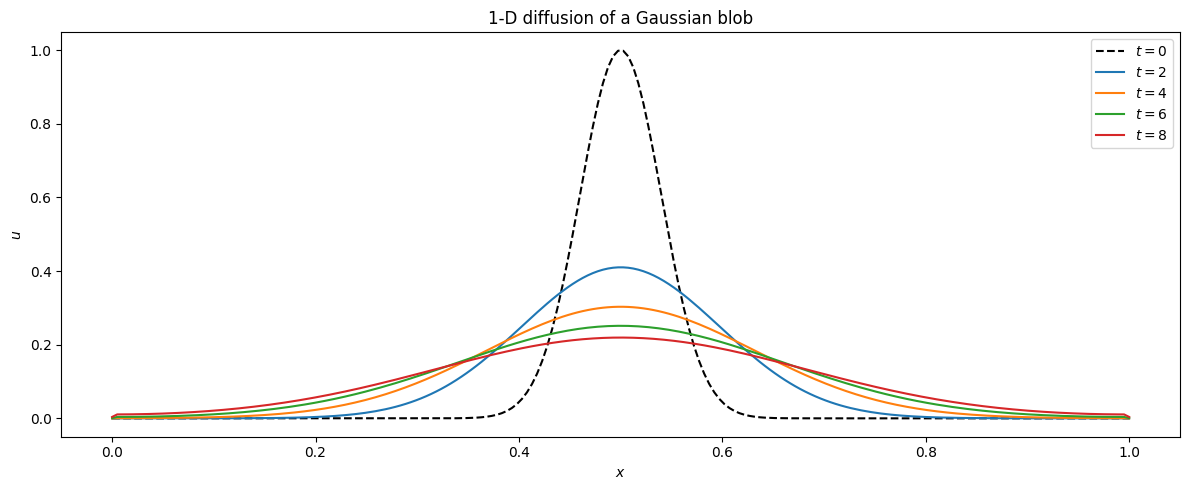

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(xd, blob0, "k--", label="$t=0$")
for k, snap in enumerate(snapshots, start=1):
    ax.plot(xd, snap, color=f"C{k - 1}", label=f"$t={2.0 * k:.0f}$")
ax.set(xlabel="$x$", ylabel="$u$", title="1-D diffusion of a Gaussian blob")
ax.legend()
fig.tight_layout()
fig.savefig(IMG_DIR / "diffusion_spread.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/phase1_fundamentals/diffusion_spread.png
:label: p1-diffusion-fig
:width: 90%

A Gaussian blob diffusing under {eq}`p1-diffusion`. Each curve is a later time; the peak drops and the profile widens while the area underneath is preserved.
```

## 3. Burgers — nonlinear steepening meets viscous smoothing

The viscous Burgers equation couples nonlinear self-advection to diffusion,

```{math}
:label: p1-burgers
\partial_t u + u\,\partial_x u = \nu\,\partial_{xx} u ,
```

and is the canonical one-dimensional caricature of the Navier–Stokes balance between inertia and viscosity {cite}`burgers1948mathematical`. Where $u$ is large the wave moves faster, so a smooth profile **steepens** on its leading edge; the viscous term resists, and the two balance in a thin front of width $\sim \nu / U$. The relevant dimensionless number is the grid **Péclet** number $\mathrm{Pe}_{\Delta} = U\,\Delta x / \nu$: when it exceeds $\sim 2$ the front is under-resolved and the upwind/WENO reconstruction (the [operators chapter](operators.ipynb)) controls the spurious oscillations.

In [8]:
burgers = Burgers1D.create(nx=256, Lx=1.0, nu=2.0e-3)
xb = jnp.linspace(0.0, 1.0, burgers.grid.Nx)
sine0 = jnp.sin(2.0 * jnp.pi * xb)
burgers_state0 = burgers.apply_boundary_conditions(Burgers1DState(u=sine0))

burgers_snaps = [sine0]
state = burgers_state0
for _ in range(3):
    sol = burgers.integrate(state, t0=0.0, t1=0.08, dt=5.0e-4)
    state = Burgers1DState(u=sol.ys.u[-1])
    burgers_snaps.append(state.u)

pe_grid = float(jnp.max(jnp.abs(sine0))) * burgers.grid.dx / burgers.params.nu
print(f"grid Peclet number  U*dx/nu = {pe_grid:.2f}")

grid Peclet number  U*dx/nu = 1.95


{numref}`p1-burgers-fig` follows the sine wave as its compressive half steepens toward a near-shock while viscosity keeps the front finite — the steepening/smoothing competition that motivates flux-limited advection schemes.

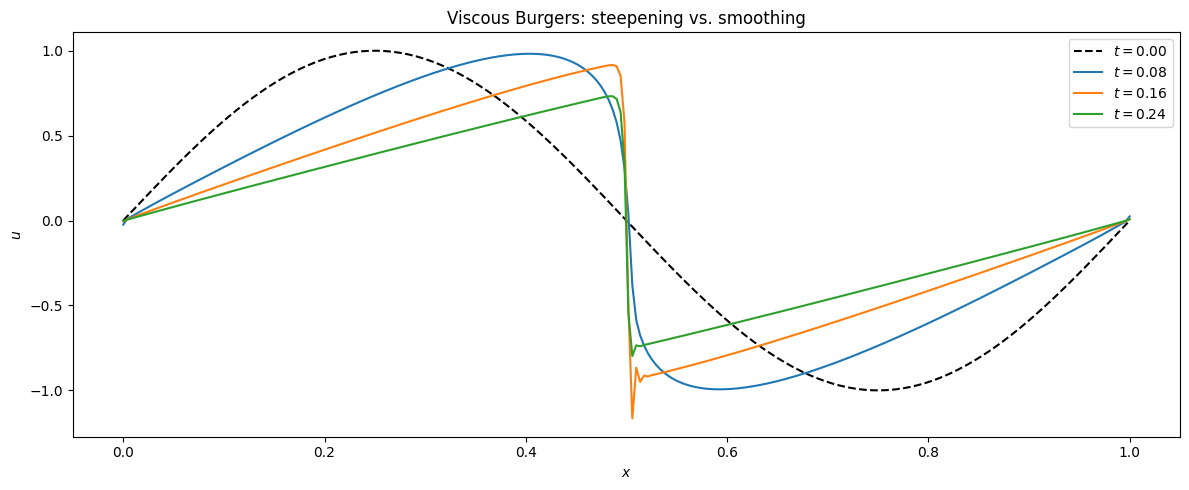

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
for k, snap in enumerate(burgers_snaps):
    style = "k--" if k == 0 else f"C{k - 1}"
    ax.plot(xb, snap, style, label=f"$t={0.08 * k:.2f}$")
ax.set(xlabel="$x$", ylabel="$u$", title="Viscous Burgers: steepening vs. smoothing")
ax.legend()
fig.tight_layout()
fig.savefig(IMG_DIR / "burgers_steepening.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/phase1_fundamentals/burgers_steepening.png
:label: p1-burgers-fig
:width: 90%

A sine wave evolving under the viscous Burgers equation {eq}`p1-burgers`. The leading edge steepens as the nonlinear flux compresses it; viscosity holds the front at finite width instead of letting it break.
```

## Summary

The three building blocks and their numerical signatures, gathered in {numref}`p1-summary-table`:

```{list-table} The three 1-D processes and the time-step limit each imposes on an explicit scheme.
:header-rows: 1
:label: p1-summary-table

* - Process
  - Equation
  - Explicit step limit
* - Advection
  - {eq}`p1-advection`
  - hyperbolic, $c\,\Delta t/\Delta x \le \mathcal{O}(1)$
* - Diffusion
  - {eq}`p1-diffusion`
  - parabolic, $\nu\,\Delta t/\Delta x^2 \le 1/2$
* - Burgers
  - {eq}`p1-burgers`
  - both, plus grid-Péclet resolution of the front
```

- Linear advection is a pure translation; the CFL number {eq}`p1-cfl` bounds the explicit step and is the ancestor of the gravity-wave CFL in the shallow-water models.
- Explicit diffusion carries the far tighter parabolic limit {eq}`p1-diffusion-cfl` — the reason somax offers an IMEX path for the stiff Laplacian.
- Burgers couples the two: the nonlinear flux steepens, viscosity smooths, and the grid Péclet number decides whether the front is resolved.

The [next chapter](phase2_spatial.ipynb) lifts these processes into two dimensions and adds the elliptic (Poisson) problem that ties velocity to pressure.